# **LLM Evaluation Metrics**

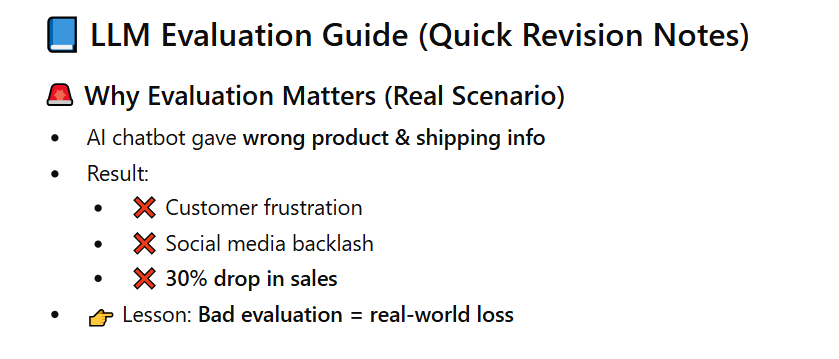

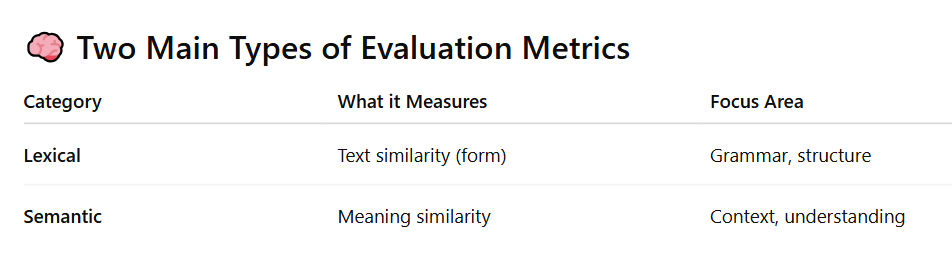

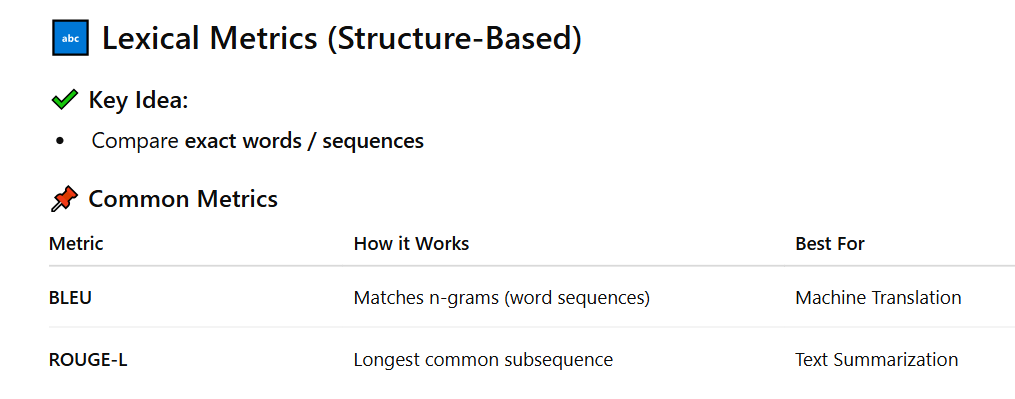

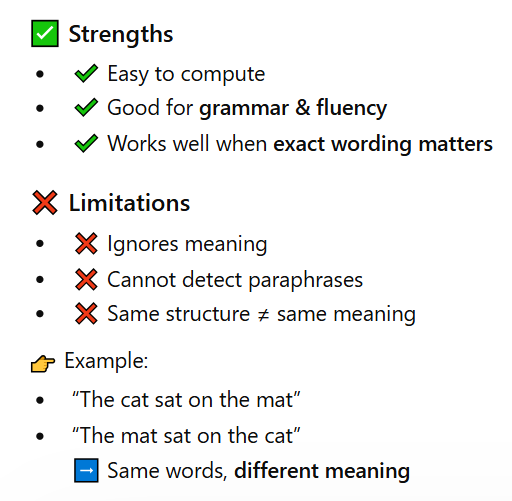

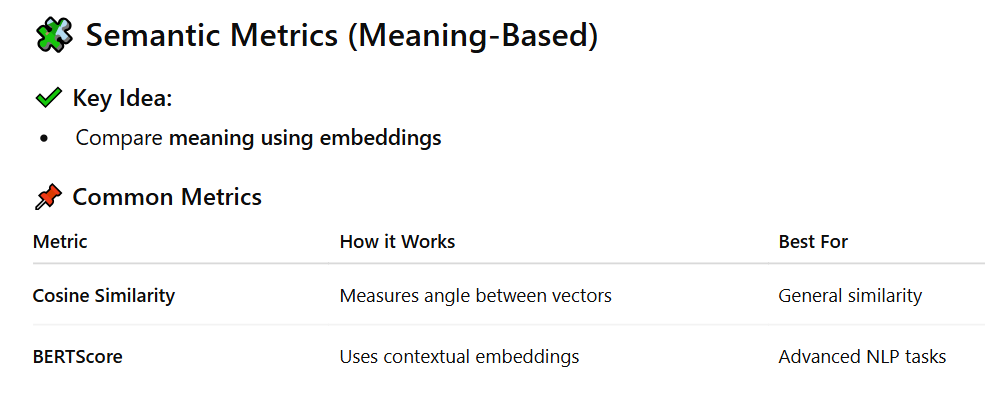

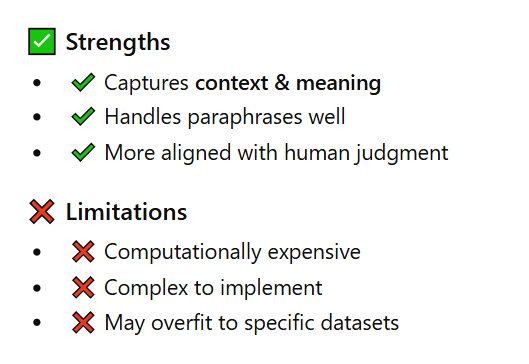

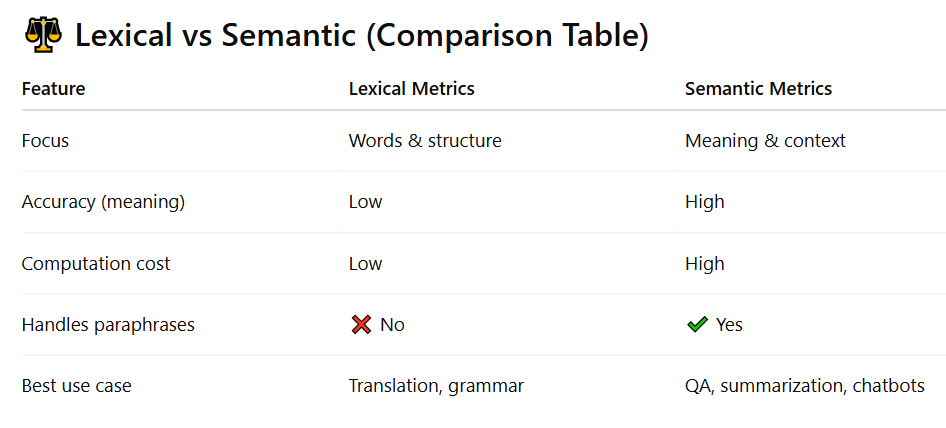

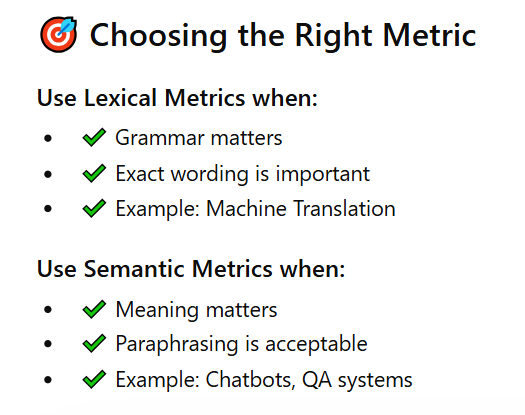

# Install Dependencies

In [1]:
!pip install nltk rouge-score scikit-learn sentence-transformers bert-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.6 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b84686512ec7ee62ccbd601e5d70cc606d586b4ed6bedcd191cf75d2c6e4e242
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


# BLEU Score (Lexical Metric)

In [3]:
import nltk
from nltk.translate.bleu_score import sentence_bleu

nltk.download('punkt')

reference = ["the cat is on the mat".split()]
candidate = "the cat is sitting on the mat".split()

bleu_score = sentence_bleu(reference, candidate)

print("BLEU Score:", bleu_score)

BLEU Score: 8.44484326442819e-78


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# ROUGE Score (Lexical Metric)

In [4]:
from rouge_score import rouge_scorer

reference = "the cat is on the mat"
candidate = "the cat is sitting on the mat"

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
scores = scorer.score(reference, candidate)

print("ROUGE-1:", scores['rouge1'])
print("ROUGE-L:", scores['rougeL'])

ROUGE-1: Score(precision=0.8571428571428571, recall=1.0, fmeasure=0.923076923076923)
ROUGE-L: Score(precision=0.8571428571428571, recall=1.0, fmeasure=0.923076923076923)


# Cosine Similarity (Semantic Metric using Embeddings)

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

reference = "the cat is on the mat"
candidate = "a cat is sitting on the mat"

embeddings = model.encode([reference, candidate])

cos_sim = cosine_similarity([embeddings[0]], [embeddings[1]])

print("Cosine Similarity:", cos_sim[0][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Cosine Similarity: 0.8983029


# BERTScore (Semantic Metric)

In [6]:
from bert_score import score

reference = ["the cat is on the mat"]
candidate = ["the cat is sitting on the mat"]

P, R, F1 = score(candidate, reference, lang="en", verbose=True)

print("BERTScore Precision:", P.mean().item())
print("BERTScore Recall:", R.mean().item())
print("BERTScore F1:", F1.mean().item())

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 1.29 seconds, 0.78 sentences/sec
BERTScore Precision: 0.9437776207923889
BERTScore Recall: 0.9596478343009949
BERTScore F1: 0.9516465663909912


# Combining all Metrices in a single block

In [13]:
reference_text = "the cat is on the mat"
candidate_text = "the cat sits on the mat"

# BLEU
from nltk.translate.bleu_score import sentence_bleu
bleu = sentence_bleu([reference_text.split()], candidate_text.split())

# ROUGE
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge = scorer.score(reference_text, candidate_text)['rougeL'].fmeasure

# Cosine Similarity
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
model = SentenceTransformer('all-MiniLM-L6-v2')
emb = model.encode([reference_text, candidate_text])
cosine = cosine_similarity([emb[0]], [emb[1]])[0][0]

# BERTScore
from bert_score import score
P, R, F1 = score([candidate_text], [reference_text], lang="en", verbose=False)
bert_f1 = F1.mean().item()

print("\n--- Evaluation Results ---")
print(f"BLEU Score: {bleu:.4f}")
print(f"ROUGE-L: {rouge:.4f}")
print(f"Cosine Similarity: {cosine:.4f}")
print(f"BERTScore F1: {bert_f1:.4f}")

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Evaluation Results ---
BLEU Score: 0.0000
ROUGE-L: 0.8333
Cosine Similarity: 0.9082
BERTScore F1: 0.9532


BLEU score is zero as there is
❌ No overlap → 4-gram precision = 0

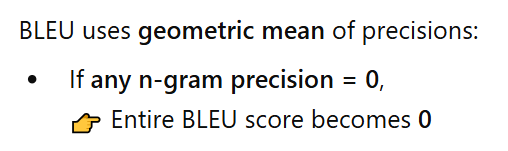

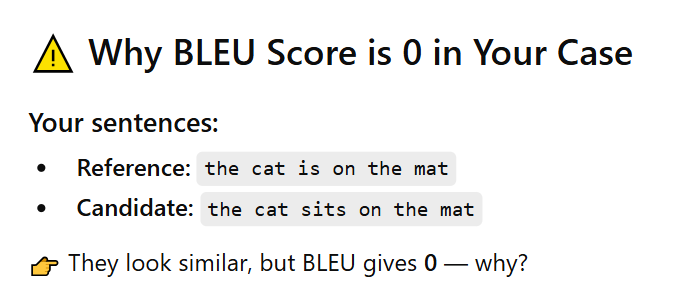

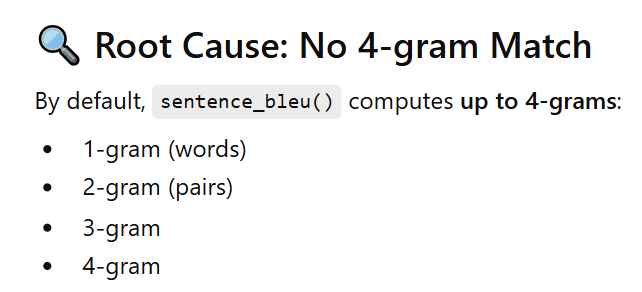

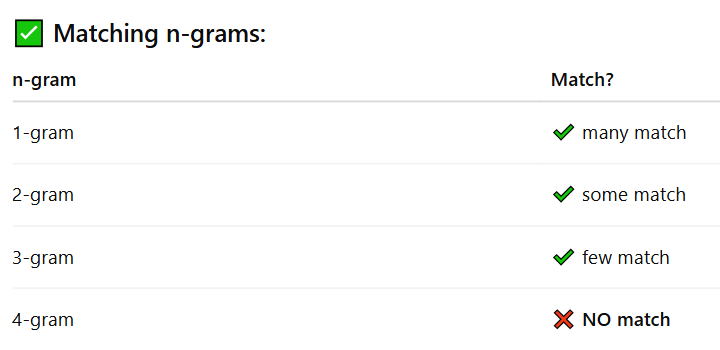

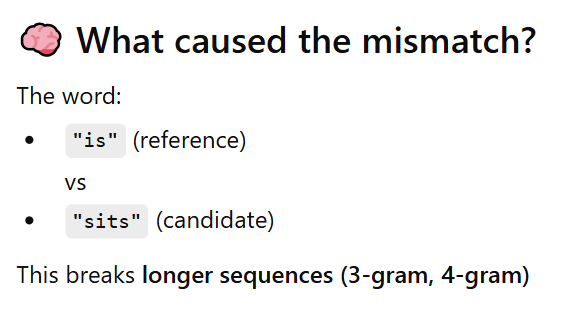

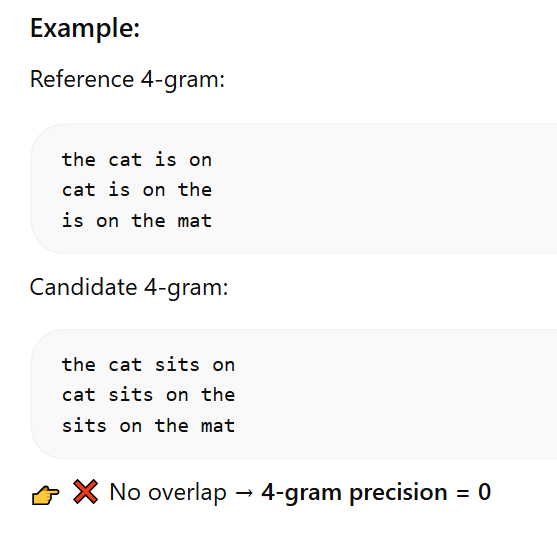

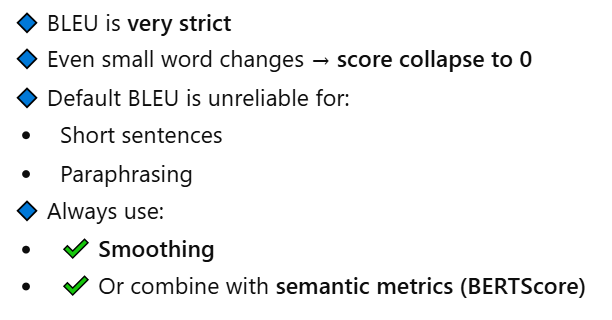

# Apply smoothing function

A smoothing function prevents the BLEU score from becoming zero when higher-order n-grams (like 3-gram or 4-gram) have no matches.


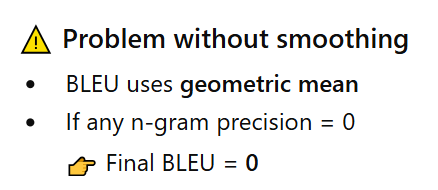

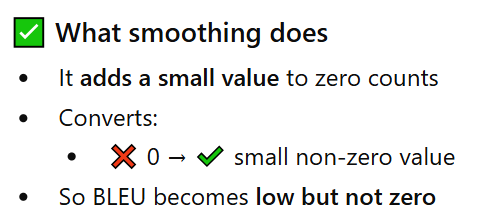

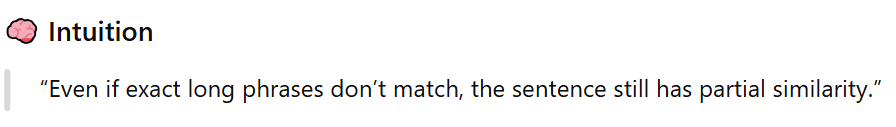

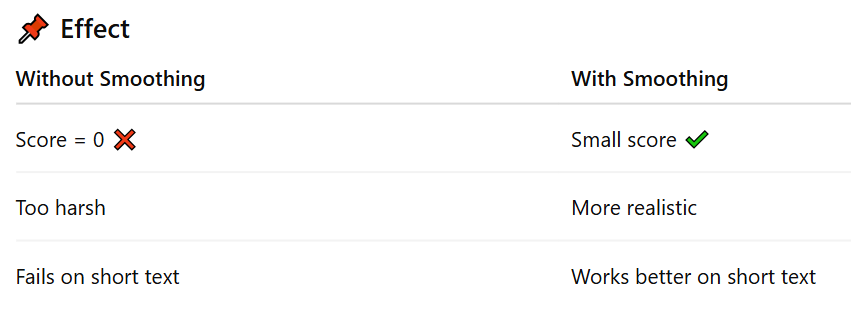

In [12]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

bleu = sentence_bleu(
    [reference_text.split()],
    candidate_text.split(),
    smoothing_function=smooth
)

print("BLEU with smoothing:", bleu)

BLEU with smoothing: 0.274941620352113


Now we get a non-zero BLEU score.

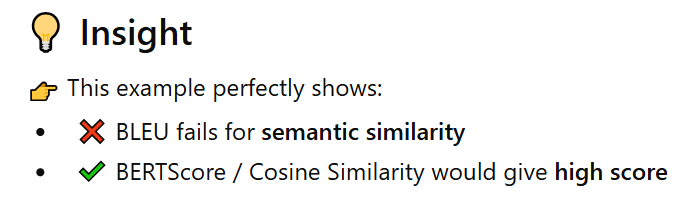